In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ExpSineSquared,
    WhiteKernel, ConstantKernel as C, DotProduct
)

from scipy.stats import multivariate_normal
from scipy.linalg import cholesky, solve_triangular

import GPy
import torch
import gpytorch

In [2]:
# y = f(x) + eps,  eps ~ N(0, sigma^2)
#
# f has two challenges:
#   1. multi-scale: slow sinusoid + fast oscillation competing
#   2. non-stationary amplitude: the fast component decays with x
# A single stationary kernel (e.g. RBF) will underfit one scale or overfit the other.

def f(x):
    return np.sin(x) * np.exp(-x / 5) + 0.5 * np.sin(5 * x)

sigma_noise = 0.2

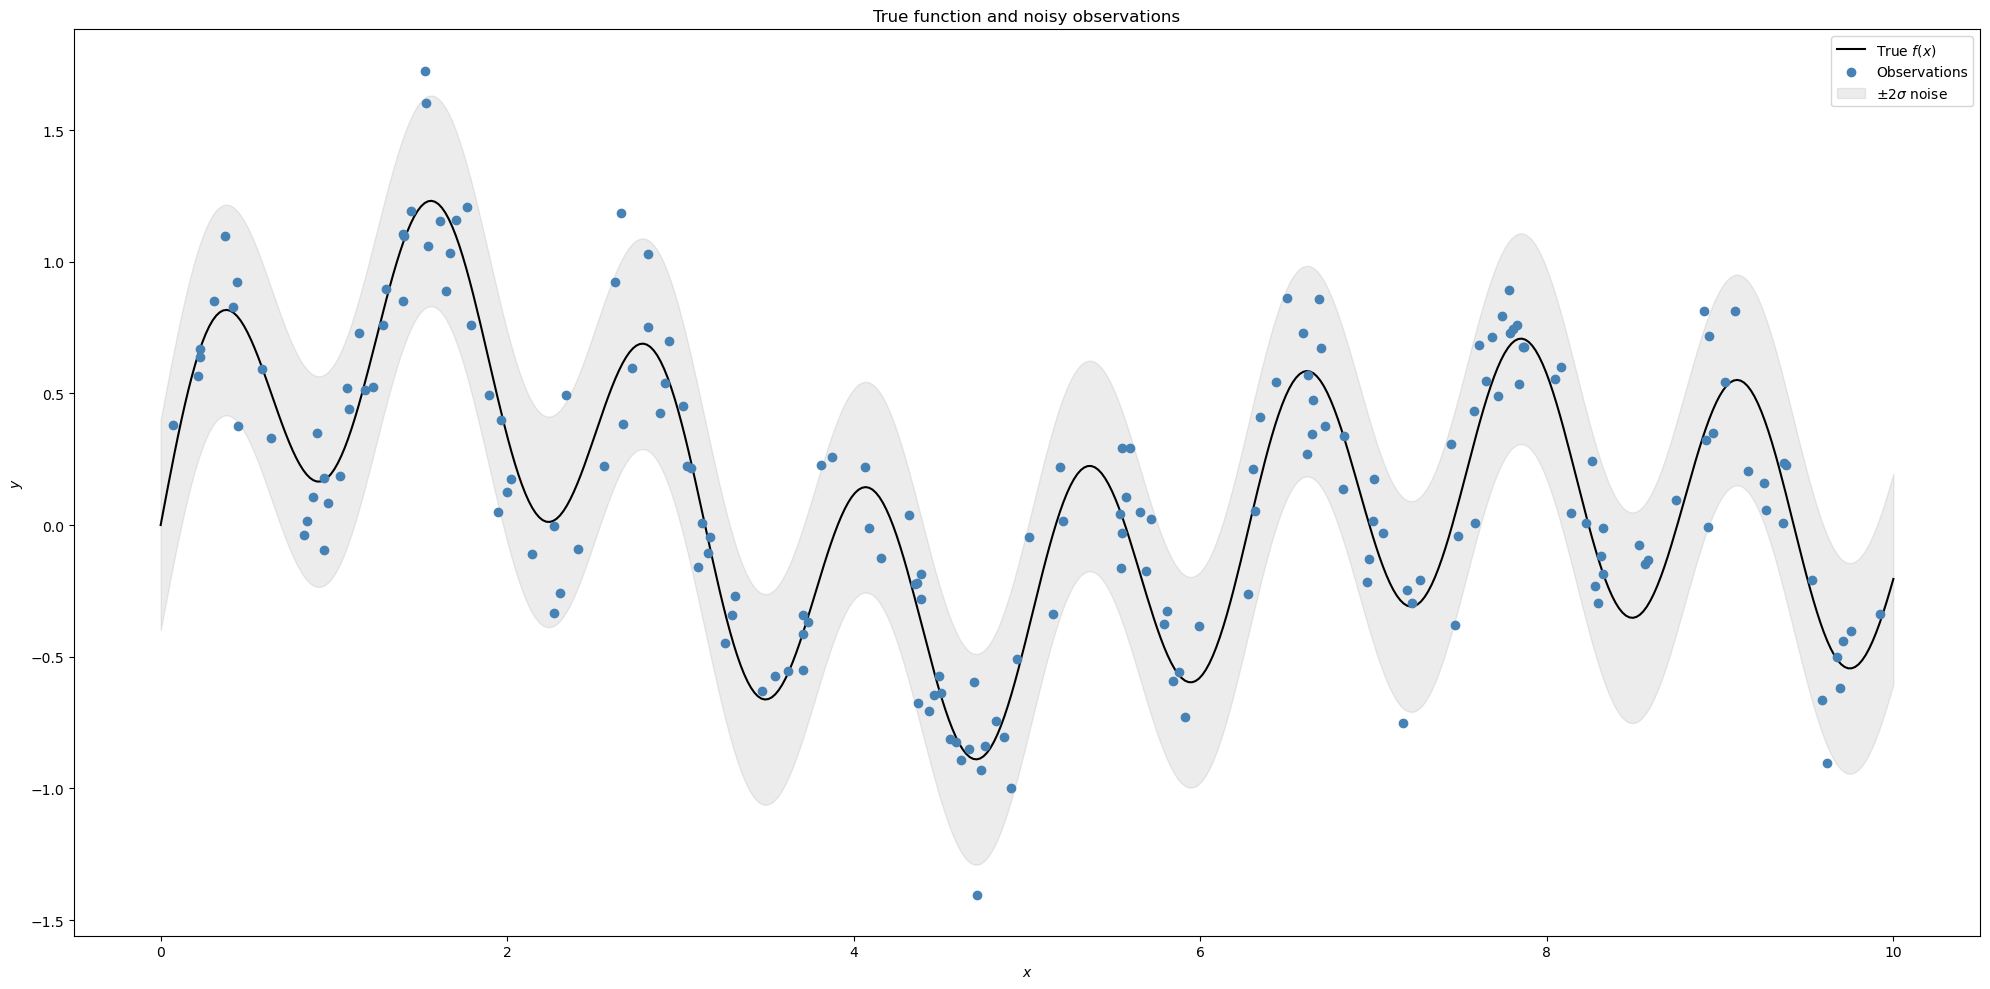

In [10]:
rng = np.random.default_rng(42)

# Dense grid for the true function
x_plot = np.linspace(0, 10, 500)
y_plot = f(x_plot)

# Sparse noisy observations
n_obs = 200
x_obs = np.sort(rng.uniform(0, 10, n_obs))
y_obs = f(x_obs) + rng.normal(0, sigma_noise, n_obs)

# Plot
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(x_plot, y_plot, "k-", lw=1.5, label="True $f(x)$")
ax.scatter(x_obs, y_obs, color="steelblue", zorder=5, label="Observations")
ax.fill_between(x_plot, y_plot - 2*sigma_noise, y_plot + 2*sigma_noise,
                alpha=0.15, color="gray", label=r"$\pm 2\sigma$ noise")
ax.set(xlabel="$x$", ylabel="$y$", title="True function and noisy observations")
ax.legend()
plt.tight_layout()
plt.show()